In [1]:
import torch
import numpy as np
from torch import nn
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

In [2]:
data = sns.load_dataset("flights")

In [3]:
data

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


<Axes: xlabel='None', ylabel='passengers'>

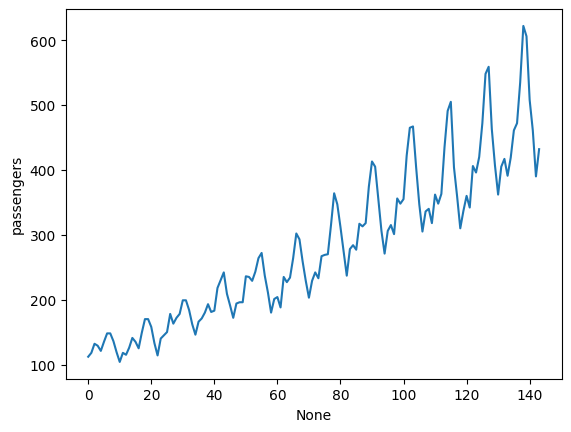

In [4]:
sns.lineplot(x=data.index, y=data.passengers, data=data)

In [5]:
xy = data.passengers.values.reshape(-1, 1)
print(xy.shape)

(144, 1)


In [6]:
xy[0]

array([112], dtype=int64)

In [7]:
sc = MinMaxScaler()
xy = sc.fit_transform(xy)

In [8]:
xy[0]

array([0.01544402])

In [9]:
seq_len = 20
X = []
y = []
for i in range(len(xy) - seq_len):
    X.append(xy[i : i+seq_len])
    y.append(xy[i+seq_len])

In [10]:
X = np.array(X)
y = np.array(y)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(105, 20, 1) (19, 20, 1) (105, 1) (19, 1)


In [13]:
class FlightDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [14]:
train_loader = DataLoader(FlightDataset(X_train, y_train), batch_size=2, shuffle=False)
test_loader = DataLoader(FlightDataset(X_test, y_test), batch_size=2, shuffle=False)

In [15]:
class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = 128
        self.num_layers = 2
        self.lstm = nn.LSTM(input_size=1, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(self.hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Use last time step
        out = self.fc1(out)
        out = self.relu(out)
        output = self.fc2(out)
        return output

In [16]:
model = LSTM()

In [17]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [18]:
# Improved training loop with validation
best_loss = float('inf')
for epoch in tqdm(range(120)):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            output = model(x)
            val_loss += loss_fn(output, y).item()

    val_loss /= len(test_loader)
    scheduler.step(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}")

  0%|                      | 1/300 [00:01<05:57,  1.19s/it]

Epoch 0, Train Loss: 0.0635, Val Loss: 0.0232


  7%|█▍                   | 21/300 [00:21<04:45,  1.02s/it]

Epoch 20, Train Loss: 0.0034, Val Loss: 0.0016


 14%|██▊                  | 41/300 [00:42<04:45,  1.10s/it]

...

 87%|█████████████████▍  | 261/300 [04:49<00:53,  1.37s/it]

Epoch 260, Train Loss: 0.0007, Val Loss: 0.0007


 94%|██████████████████▋ | 281/300 [05:17<00:25,  1.37s/it]

Epoch 280, Train Loss: 0.0008, Val Loss: 0.0007


100%|████████████████████| 300/300 [05:42<00:00,  1.14s/it]


<Axes: >

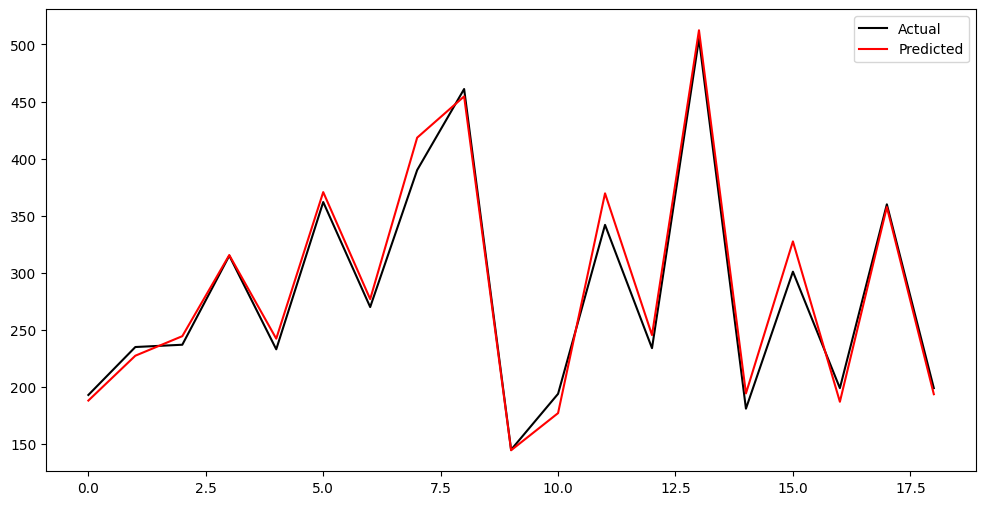

In [20]:
model.eval()
y_pred_list = []
y_actual_list = []

with torch.no_grad():
    for x, y in test_loader:
        y_pred = model(x)
        y_pred_list.append(y_pred.numpy())
        y_actual_list.append(y.numpy())

y_pred_all = np.concatenate(y_pred_list).squeeze()
y_actual_all = np.concatenate(y_actual_list).squeeze()

# Inverse transform to original scale
y_pred_original = sc.inverse_transform(y_pred_all.reshape(-1, 1))
y_actual_original = sc.inverse_transform(y_actual_all.reshape(-1, 1))

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(y_actual_original)), y=y_actual_original.squeeze(), label='Actual', color='black')
sns.lineplot(x=range(len(y_pred_original)), y=y_pred_original.squeeze(), label='Predicted', color='red')